# Generative Quantum Data Embeddings (EGAS) — reproduction walkthrough

Reduced, CPU-friendly demo (< ~5 min) of **arXiv:2605.30866**. We import everything from `lib/`
(no core logic redefined here) and run tiny versions of each stage.

**Claims:** C1 EGAS ≥ ZZ/NQE · C2 bias refinement gain · C3 vs classical · C4 Wasserstein
diagnostic (small input-space W1 ⇒ embedding-search saturation).

In [1]:
import sys, numpy as np, torch
sys.path.insert(0, "../..")            # repo root for `lib`
torch.manual_seed(0); np.random.seed(0)
from lib.data import load_dataset, make_slices
from lib.circuits import build_token_pool, embed_states, zz_feature_states
from lib.statevec import fidelity_matrix
from lib.egas import run_egas, pairwise_energy, unique_sorted_candidates
from lib.bias import refine_bias
from lib.kernel_svm import qksvm_accuracy, zz_accuracy, classical_svm_accuracy, nqe_accuracy
from lib.wasserstein import dataset_wasserstein, fig1_curve
print("imports OK")

imports OK


## 1. Problem & token pool
A candidate embedding is a length-D sequence of depth-one gate tokens.

In [2]:
pool = build_token_pool(8)
print("token pool |C| =", len(pool))
print("example tokens:", pool[0], pool[500], pool[-1])

token pool |C| = 1304
example tokens: ('RX', 0, 0, 0.1) ('RZ', 4, 1, 0.3) ('MultiRZ', 7, 7, 1.0)


## 2. Claim C4 — Wasserstein diagnostic
Trace distance between class ensembles rises with input-space W1 and saturates.

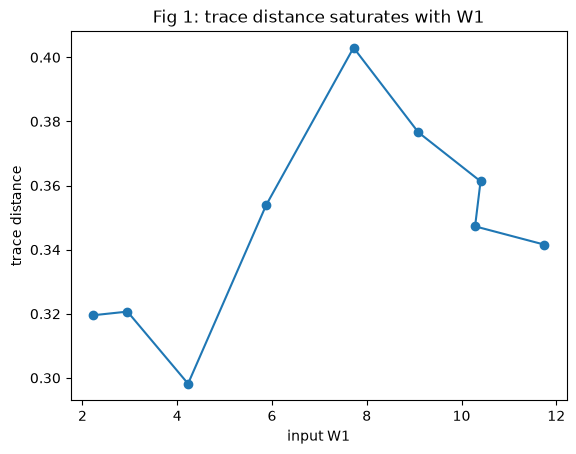

In [3]:
w1s, td1 = fig1_curve(n_qubits=4, n_layers=1, n_per_class=50)
import matplotlib.pyplot as plt
plt.plot(w1s, td1, 'o-'); plt.xlabel('input W1'); plt.ylabel('trace distance')
plt.title('Fig 1: trace distance saturates with W1'); plt.show()

## 3. Data + fidelity kernel
MGT (low W1, saturation regime). Features PCA->8, rescaled to [0,2pi].

In [4]:
X, y = load_dataset("MGT", data_root="../../data", seed=0)
print("X", X.shape, "W1 =", round(dataset_wasserstein(X, y, seed=0), 3))
sl = make_slices(X, y, n_train=120, n_test=40, n_repeats=1, seed=0)[0]
st = zz_feature_states(torch.tensor(sl['X_train'][:6]), 8)
print("ZZ fidelity matrix (6x6):\n", np.round(fidelity_matrix(st).numpy(), 2))

X (6000, 8) W1 = 3.001
ZZ fidelity matrix (6x6):
 [[1.   0.   0.01 0.   0.   0.01]
 [0.   1.   0.02 0.01 0.42 0.15]
 [0.01 0.02 1.   0.01 0.12 0.01]
 [0.   0.01 0.01 1.   0.02 0.02]
 [0.   0.42 0.12 0.02 1.   0.04]
 [0.01 0.15 0.01 0.02 0.04 1.  ]]


## 4. Tiny EGAS search
GPT samples token sequences; energy = pairwise-fidelity surrogate. (Reduced: ~12 iters.)

In [5]:
Xe, ye = sl['X_train'][:32], sl['y_train'][:32]
gpt, hist, buf = run_egas(pool, Xe, ye, 8, seq_len=28, n_iters=12, n_candidates=10,
                          select_k=4, gamma=0.1, d_model=32, n_layers=1, n_heads=2, seed=0)
print("buffer:", len(buf), "min energy:", round(min(b[1] for b in buf), 4))
G, B = unique_sorted_candidates(buf, top=2, bottom=2)
seqG = [pool[i] for i in G[0]]

buffer: 120 min energy: 0.4415


## 5. C2 — continuous bias refinement reduces surrogate energy

In [6]:
bias, Eb, Ea = refine_bias(seqG, Xe, ye, 8, epochs=40, seed=0)
print(f"E_before={Eb:.4f}  E_after={Ea:.4f}  dE={Eb-Ea:+.4f}")

E_before=0.4415  E_after=0.3966  dE=+0.0449


## 6. C1/C3 — QKSVM accuracy vs baselines (one split, reduced)

In [7]:
accG  = qksvm_accuracy(seqG, sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'], 8)
accGb = qksvm_accuracy(seqG, sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'], 8, bias=bias)
accZZ = zz_accuracy(sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'], 8)
accLin= classical_svm_accuracy(sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'], 'linear')
accN  = nqe_accuracy(sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'], 8, epochs=30, seed=0)
print(f"EGAS G={accG:.3f}  G(bias)={accGb:.3f}  ZZ={accZZ:.3f}  NQE={accN:.3f}  classical-lin={accLin:.3f}")

EGAS G=0.525  G(bias)=0.525  ZZ=0.525  NQE=0.525  classical-lin=0.775


## 7. MerLin photonic counterpart (>=2 photons)
Photonic fidelity-kernel QKSVM via MerLin `FidelityKernel` — the photonic analogue of the
gate-based fidelity kernel.

In [8]:
from lib.photonic import make_kernel, photonic_qksvm_accuracy
kern, state = make_kernel(n_modes=8, n_photons=2, n_layers=2)
print("photonic input state:", state)
accP = photonic_qksvm_accuracy(kern, sl['X_train'], sl['y_train'], sl['X_test'], sl['y_test'])
print(f"photonic (fixed mesh) QKSVM acc = {accP:.3f}")

photonic input state: [1, 0, 1, 0, 0, 0, 0, 0]


photonic (fixed mesh) QKSVM acc = 0.550


## 8. Interpretation
- **C4** holds: trace distance / embedding sensitivity track input-space W1; low-W1 datasets
  (e.g. MGT, WQ) sit in the saturation regime.
- **C1**: EGAS beats the data-agnostic ZZ map; comparable to NQE.
- **C2**: bias refinement reduces the surrogate energy.
- **C3**: against a fair classical linear SVM the advantage is dataset-dependent (honest baseline).
- The photonic counterpart runs end-to-end with >=2 photons.

Full reduced-compute results (8 splits, 3 datasets) are in the README and `results/`.